**importar las librerias **
se importan las librerias para utilizar los arreglos, oraganizar los datos y realizar gráficas.

In [238]:
#importamos las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**creacion de datos de entrada y salida **
Se fija una semilla para obtener resultados reproducibles, se genera una serie de datos de 0 a 99 con incrementos de 0.1 y se aplica la función seno con ruido para simular un comportamiento realista. Luego, se grafica la serie para visualizarla y se organiza en una tabla de una sola columna.

In [239]:
#fijamos las semill para que siempre sea los mismos resultados
np.random.seed(0)
#creacion de coleccion de datos aleatorios que inician en0 y va hasta 99 teniendo
#en cuenta que cada vez auentan 0.1, el np.sin es para crear una onda y se le aumenta un ruido
data = np.sin(np.arange(0, 100, 0.1)) + np.random.normal(0, 0.1, 1000)

        valor
0    0.176405
1    0.139849
2    0.296543
3    0.519610
4    0.576174
..        ...
995 -0.816508
996 -0.822036
997 -0.729163
998 -0.782349
999 -0.625736

[1000 rows x 1 columns]


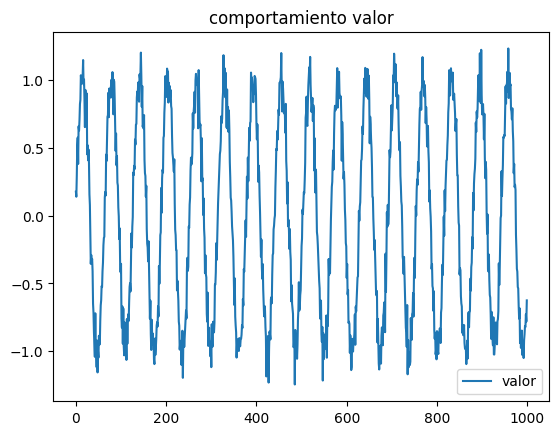

In [240]:
#convierte la coleccion de  datos en una tabla con solo una columna
df = pd.DataFrame(data, columns=['valor'])
print(df)
#se crea una grafica con los datos de inicio para evidenciar la serie de datos creados
df.plot(title="comportamiento valor")
plt.show()

**creacion de la secuencia: **
Se implementa una función que convierte la colección de datos en entradas y salidas para el modelo, recorriendo la base de datos y tomando cada 2 datos como entrada para predecir el siguiente valor

In [241]:
#se implementa la función para transformar la coleccion de datos
#en datos de entrada y salida para el modelo
def crear_secuencias(data, valores_predecir):
   #defiene los arreglos de entrada y de salida
    X, y = [], []
    #se crea ciclo para recorrer los
    for i in range(len(data) - valores_predecir):
        #guarda una secuencia de datos para los datos de variables de entrada
        X.append(data[i:i+valores_predecir])
        #guarda una secuencia de datos para los datos de variables de salida
        y.append(data[i+valores_predecir])
    return np.array(X), np.array(y)
#estamos diciendo que cada 2 datos se toma el valor de salida
valores_predecir = 1
X, y = crear_secuencias(df['valor'].values, valores_predecir)


**dividir los datos: **
se define que la cantidad de datos se va utilizar un 80% para el entrenamiento y para la provar el modelo el 20%, adicional se define las variables teniendo en cuenta desde donde toma los datos y hasta donde va para ser utilizados para el entrenamiento y la evaluacion.

In [242]:
#se define que para entrenar se toma el 80% y para provar el 20%
split = int(0.8 * len(X))
#se define los valores de entrenamiento para que aprenda desde el inicio de la posicion
#posicion hasta el final  y el test para evaluar el modelo
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


**se crea el modelo**
Se importan las herramientas necesarias y se define un modelo LSTM con 50 neuronas y función de activación tanh, utilizando las variables de entrada para generar una única predicción.

In [243]:
#se importa las herramientas para crear la red neuronal y utlizar el modelo LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
#se crea el modelo con 50 nueronas, con la funcion matematica tanh y con los valores para predecir y una variable
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(valores_predecir, 1)),
   #da un solo resultado para la predicicion
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**compilar**
Se ajustan automáticamente los pesos del modelo durante el entrenamiento, se evalúa el error y se muestra la estructura de la red neuronal.

In [244]:
#se ajusta los valores referente a los pesos automaticamente y mide el error
model.compile(optimizer='adam', loss='mse')
#muestra la estructura
model.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

**entrenar**
El modelo ejecuta un proceso iterativo en el que, a partir de los valores de entrada y salida, realiza predicciones, calcula el error y ajusta los pesos de la red para mejorar su desempeño. Este entrenamiento se lleva a cabo durante 20 iteraciones (épocas), optimizando progresivamente el aprendizaje sobre los datos.

In [245]:
#modelo genera un ciclo para predecir, calcular el error y ajustando los pesos
#al modelo se le ingresa los valores de entrada y salida
# utiliza y crea una interaccion de 20 veces y entrena los grupos
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.4896 - val_loss: 0.4628
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4068 - val_loss: 0.3793
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3277 - val_loss: 0.2965
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2489 - val_loss: 0.2152
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1734 - val_loss: 0.1402
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1088 - val_loss: 0.0811
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0623 - val_loss: 0.0446
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0370 - val_loss: 0.0281
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0274 - val_loss: 0.0235
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0250 - val_loss: 0.0227
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0248 - val_loss: 0.0226
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0247 - val_

**Evalua**
Se calcula el error del modelo usando MSE, comparando las predicciones con los valores reales para evaluar su desempeño.

In [246]:
#importa el medidor de error
from sklearn.metrics import mean_squared_error
#predice los valores nuevos
predicciones = model.predict(X_test)
#calcula la efectividad de lo que predijo
mse = mean_squared_error(y_test, predicciones)
#muestra la cantidad de error
print("Error:", mse)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Error: 0.022616465092819144


**creacion de la gráfica**
Se genera una gráfica que compara los valores reales con las predicciones del modelo, permitiendo visualizar su desempeño. Se define el tamaño de la figura, se trazan ambas series en la misma gráfica con sus respectivas etiquetas, se añade una leyenda y un título descriptivo, y finalmente se muestra el resultado.

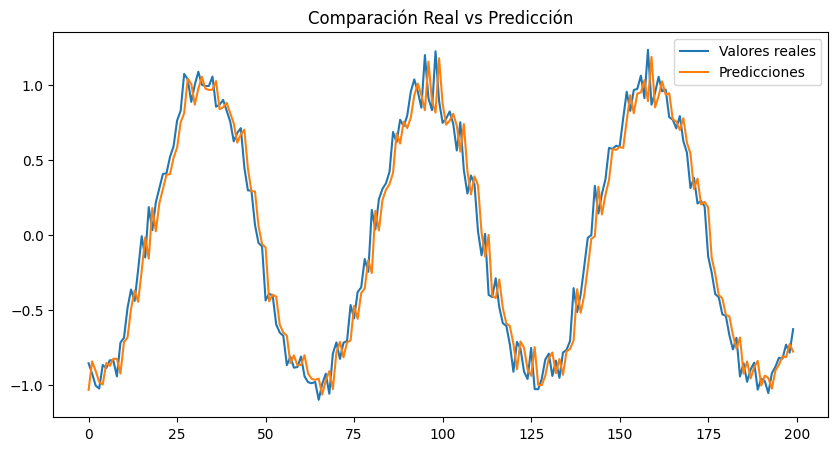

In [247]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Valores reales')
plt.plot(predicciones, label='Predicciones')
plt.legend()
plt.title("Comparación Real vs Predicción")
plt.show()